# World Cup final order-book analysis

This notebook uses a **read-only** SQLite connection and only `SELECT` queries. It deliberately filters the large snapshot table in SQL before bringing data into pandas.

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# This URI prevents writes, including accidental schema changes.
DB_PATH = (Path.cwd() / 'final' / 'world_cup_final_orderbooks.sqlite3').resolve()
if not DB_PATH.exists():
    DB_PATH = (Path.cwd() / 'world_cup_final_orderbooks.sqlite3').resolve()
assert DB_PATH.exists(), f'Database not found: {DB_PATH}'
conn = sqlite3.connect(f'file:{DB_PATH.as_posix()}?mode=ro', uri=True)
print(f'Read-only database: {DB_PATH}')

Read-only database: C:\Users\eliis\Desktop\polymarket-alpha-bot-v1\final\world_cup_final_orderbooks.sqlite3


In [3]:
# Available tables and their schemas.
tables = pd.read_sql_query("SELECT name, sql FROM sqlite_master WHERE type = 'table' ORDER BY name", conn)
for _, row in tables.iterrows():
    print(f'\n--- {row["name"]} ---')
    print(row['sql'])
tables[['name']]


--- sessions ---
CREATE TABLE sessions (
            session_id INTEGER PRIMARY KEY,
            session_start_utc TEXT NOT NULL,
            session_end_utc TEXT,
            snapshot_interval_seconds REAL NOT NULL,
            number_of_markets INTEGER NOT NULL,
            number_of_tokens INTEGER NOT NULL,
            stop_reason TEXT
        )

--- top_of_book_snapshots ---
CREATE TABLE top_of_book_snapshots (
            snapshot_id INTEGER PRIMARY KEY,
            session_id INTEGER NOT NULL REFERENCES sessions(session_id),
            timestamp_utc TEXT NOT NULL,
            token_id TEXT NOT NULL,
            market_id TEXT NOT NULL,
            market_question TEXT NOT NULL,
            outcome TEXT NOT NULL,
            priority_tier TEXT,
            analysis_category TEXT,
            best_bid TEXT,
            best_bid_size TEXT,
            best_ask TEXT,
            best_ask_size TEXT,
            midpoint TEXT,
            spread TEXT,
            latest_exchange_time

,name
0,sessions
1,top_of_book_snapshots


In [4]:
sessions = pd.read_sql_query('SELECT * FROM sessions ORDER BY session_id', conn)
sessions

,session_id,session_start_utc,session_end_utc,snapshot_interval_seconds,number_of_markets,number_of_tokens,stop_reason
0,1,2026-07-19T17:59:33.878+00:00,2026-07-19T22:04:11.486+00:00,1.0,49,98,unknown


In [5]:
summary = pd.read_sql_query("""
SELECT
    COUNT(*) AS total_snapshot_rows,
    COUNT(DISTINCT token_id) AS unique_tokens,
    COUNT(DISTINCT market_id) AS unique_markets,
    MIN(timestamp_utc) AS first_timestamp_utc,
    MAX(timestamp_utc) AS last_timestamp_utc,
    100.0 * AVG(top_of_book_changed) AS pct_top_of_book_changed,
    100.0 * AVG(CASE WHEN best_bid IS NULL OR best_ask IS NULL THEN 1 ELSE 0 END) AS pct_missing_bid_or_ask
FROM top_of_book_snapshots
""", conn)
summary.round(3)

,total_snapshot_rows,unique_tokens,unique_markets,first_timestamp_utc,last_timestamp_utc,pct_top_of_book_changed,pct_missing_bid_or_ask
0,1437660,98,49,2026-07-19T17:59:37.094+00:00,2026-07-19T22:04:10.890+00:00,17.781,28.517


In [6]:
rows_per_token = pd.read_sql_query("""
SELECT token_id, MIN(market_question) AS market_question, MIN(outcome) AS outcome, COUNT(*) AS rows
FROM top_of_book_snapshots
GROUP BY token_id
ORDER BY rows DESC, market_question, outcome
""", conn)
rows_per_token

,token_id,market_question,outcome,rows
0,50224683305525930795637556259236786272907665223902846135542340441464287900745,Argentina leading at halftime?,NO,14670
1,20664793222331339343552998267820854019645651559348706346914375656718469924729,Argentina leading at halftime?,YES,14670
2,52462745552966070037353896544408106239819915353248296777169963883406867728145,Argentina to score first vs. Spain?,NO,14670
3,91613958020462206796604703490892509074037827032000264303930178637905513667554,Argentina to score first vs. Spain?,YES,14670
4,115532626142313927461775745971979071509617704061524712572364329213373024080150,David Raya: 3+ saves,NO,14670
...,...,...,...,...
93,84190757399072369953984309564712107413581409550888657675333315797067840764739,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Extra Time?,YES,14670
94,32284767547048252961649913625466747166388451973274015022841459907301085220513,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Penalty Shootout?,NO,14670
95,87104229334397334915272757045675370538886285387392973279468710588049690692223,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Penalty Shootout?,YES,14670
96,27389181380073282932518710344836923682927012254981905347738805666697112669549,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Regular Time?,NO,14670


## Core final markets

These six markets cover regulation outcomes, the draw, advancement, the first goal threshold, and both teams scoring. The query returns only their token-level rows and only the columns used in the plots.

In [7]:
selected_markets = {
    'Argentina regulation win': '2941976',
    'Spain regulation win': '2941974',
    'Draw': '2941975',
    'Team to advance': '2942083',
    'Over/under 0.5': '2942074',
    'Both teams to score': '2945083',
}
placeholders = ','.join('?' for _ in selected_markets)
core = pd.read_sql_query(f"""
SELECT timestamp_utc, token_id, market_id, market_question, outcome,
       best_bid, best_bid_size, best_ask, best_ask_size, midpoint, spread, top_of_book_changed
FROM top_of_book_snapshots
WHERE market_id IN ({placeholders})
ORDER BY timestamp_utc, market_id, outcome
""", conn, params=list(selected_markets.values()))
numeric = ['best_bid', 'best_bid_size', 'best_ask', 'best_ask_size', 'midpoint', 'spread']
core['timestamp_utc'] = pd.to_datetime(core['timestamp_utc'], utc=True)
core[numeric] = core[numeric].apply(pd.to_numeric, errors='coerce')
core['series'] = core['market_question'] + ' — ' + core['outcome']
print(f'Loaded {len(core):,} rows for {core.market_id.nunique()} markets / {core.token_id.nunique()} tokens.')
core[['market_id', 'market_question', 'outcome']].drop_duplicates().sort_values(['market_id', 'outcome'])

Loaded 176,040 rows for 6 markets / 12 tokens.


,market_id,market_question,outcome
0,2941974,Will Spain win on 2026-07-19?,NO
1,2941974,Will Spain win on 2026-07-19?,YES
2,2941975,Will Spain vs. Argentina end in a draw?,NO
3,2941975,Will Spain vs. Argentina end in a draw?,YES
4,2941976,Will Argentina win on 2026-07-19?,NO
5,2941976,Will Argentina win on 2026-07-19?,YES
6,2942074,Spain vs. Argentina: O/U 0.5,NO
7,2942074,Spain vs. Argentina: O/U 0.5,YES
8,2942083,Spain vs. Argentina: Team to Advance,NO
9,2942083,Spain vs. Argentina: Team to Advance,YES


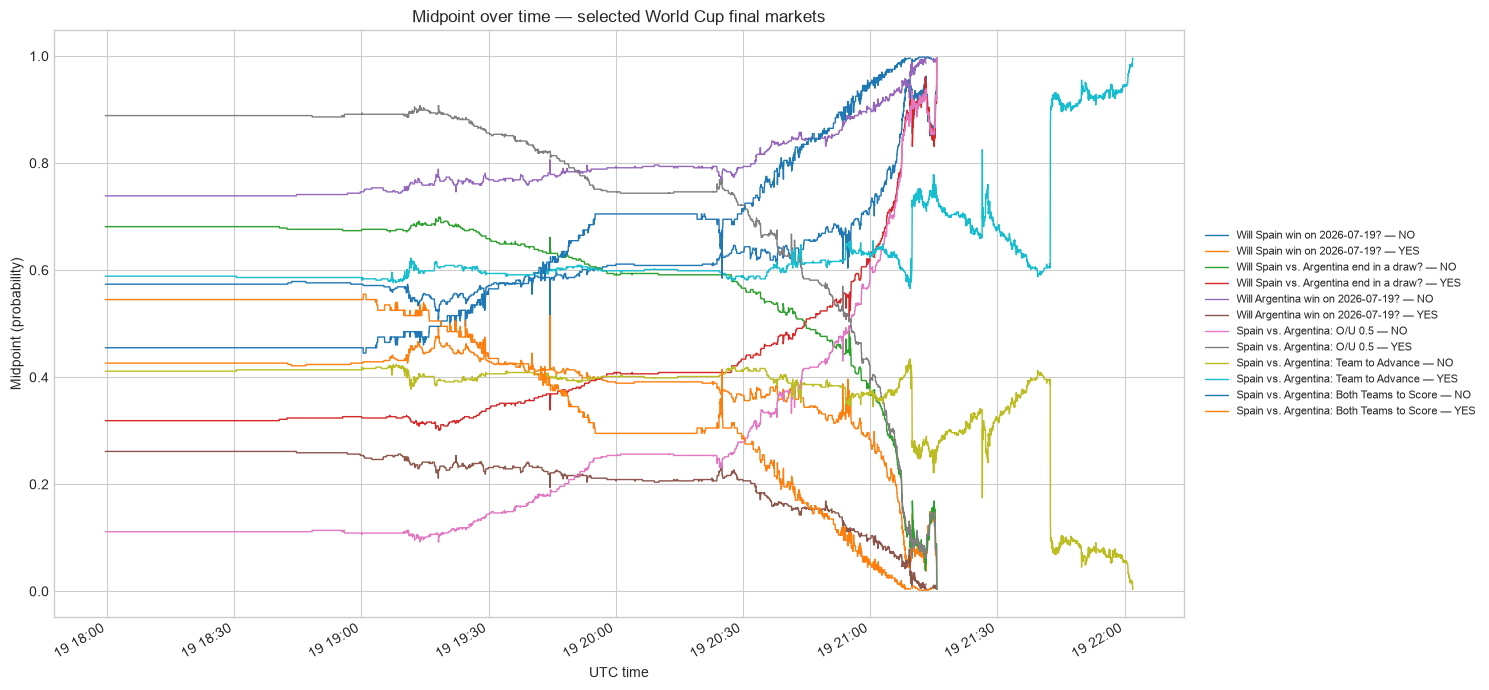

In [8]:
# One midpoint line for each YES/NO token in the selected markets.
fig, ax = plt.subplots(figsize=(15, 7))
for label, group in core.groupby('series', sort=False):
    ax.plot(group['timestamp_utc'], group['midpoint'], label=label, linewidth=1)
ax.set(title='Midpoint over time — selected World Cup final markets', xlabel='UTC time', ylabel='Midpoint (probability)')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

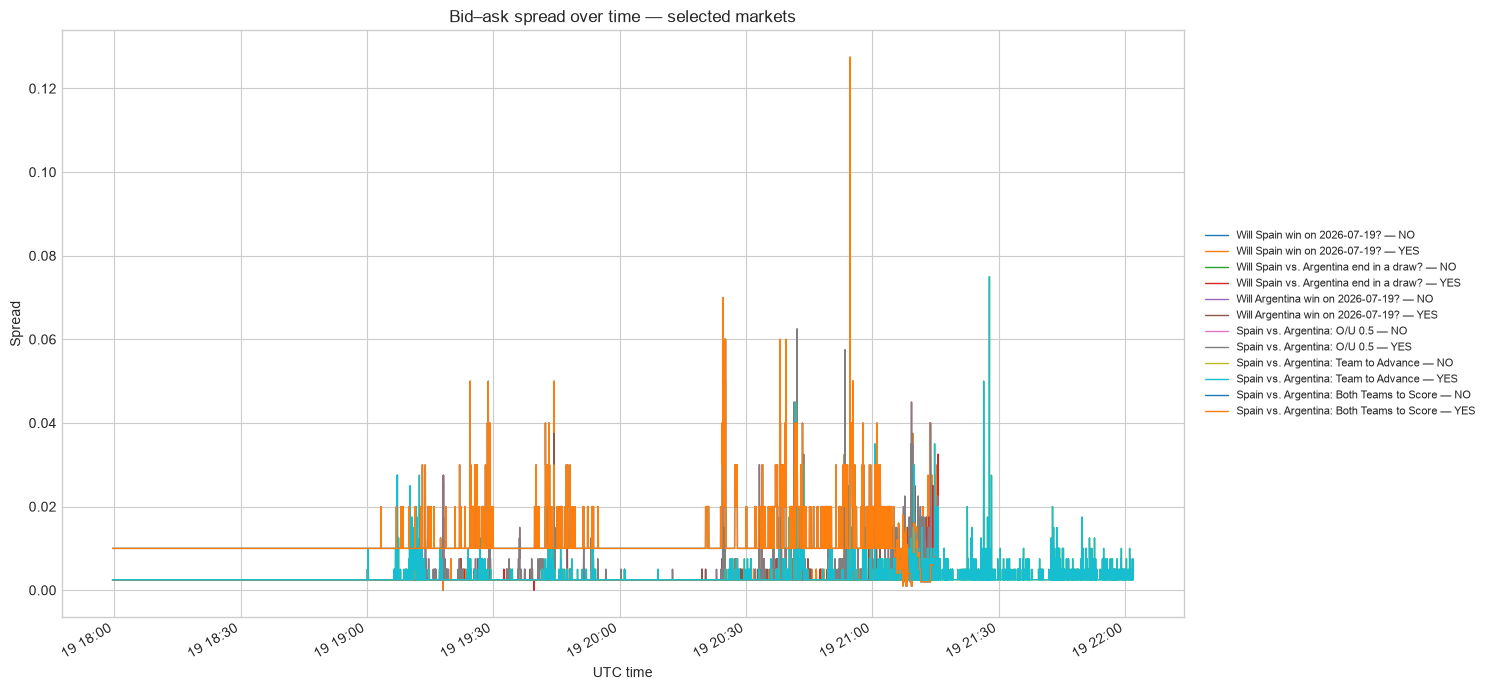

In [9]:
fig, ax = plt.subplots(figsize=(15, 7))
for label, group in core.groupby('series', sort=False):
    ax.plot(group['timestamp_utc'], group['spread'], label=label, linewidth=1)
ax.set(title='Bid–ask spread over time — selected markets', xlabel='UTC time', ylabel='Spread')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

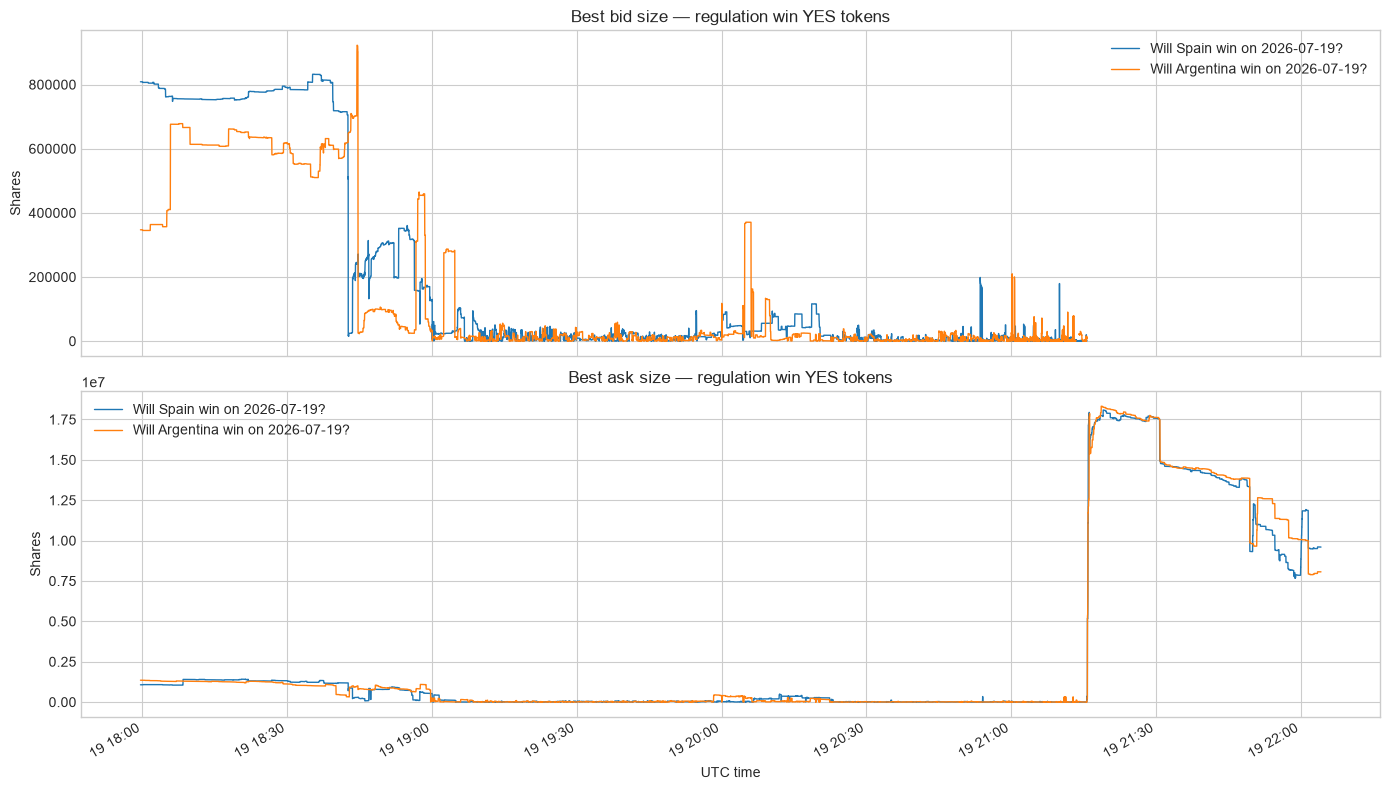

In [10]:
# Liquidity at the top of book for the two regulation-win YES tokens.
liquidity = core[(core['market_id'].isin(['2941976', '2941974'])) & (core['outcome'] == 'YES')]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for label, group in liquidity.groupby('market_question', sort=False):
    axes[0].plot(group['timestamp_utc'], group['best_bid_size'], label=label, linewidth=1)
    axes[1].plot(group['timestamp_utc'], group['best_ask_size'], label=label, linewidth=1)
axes[0].set(title='Best bid size — regulation win YES tokens', ylabel='Shares')
axes[1].set(title='Best ask size — regulation win YES tokens', xlabel='UTC time', ylabel='Shares')
for ax in axes:
    ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Largest one-second midpoint moves

SQLite finds the candidates with a window function; pandas receives only the top moves and a compact ±2-second context around each one.

In [11]:
largest_moves = pd.read_sql_query("""
WITH ordered AS (
  SELECT timestamp_utc, token_id, market_id, market_question, outcome, midpoint,
         LAG(midpoint) OVER (PARTITION BY token_id ORDER BY timestamp_utc) AS previous_midpoint,
         LAG(timestamp_utc) OVER (PARTITION BY token_id ORDER BY timestamp_utc) AS previous_timestamp
  FROM top_of_book_snapshots
), moves AS (
  SELECT *, ABS(CAST(midpoint AS REAL) - CAST(previous_midpoint AS REAL)) AS midpoint_change
  FROM ordered
  WHERE midpoint IS NOT NULL AND previous_midpoint IS NOT NULL
    AND ABS(strftime('%s', timestamp_utc) - strftime('%s', previous_timestamp)) <= 2
)
SELECT * FROM moves ORDER BY midpoint_change DESC LIMIT 12
""", conn)
largest_moves['timestamp_utc'] = pd.to_datetime(largest_moves['timestamp_utc'], utc=True)
largest_moves['previous_timestamp'] = pd.to_datetime(largest_moves['previous_timestamp'], utc=True)
largest_moves

,timestamp_utc,token_id,market_id,market_question,outcome,midpoint,previous_midpoint,previous_timestamp,midpoint_change
0,2026-07-19 19:36:13.865000+00:00,53868059366140674181460329985940983860930842520974281598176141918488476311408,2944556,Lionel Messi: 3+ shots,NO,0.67,0.25,2026-07-19 19:36:12.887000+00:00,0.420
1,2026-07-19 19:36:13.865000+00:00,15093703015426976209236306413394207170210129289842398183903524800537664396532,2944556,Lionel Messi: 3+ shots,YES,0.33,0.75,2026-07-19 19:36:12.887000+00:00,0.420
2,2026-07-19 22:01:52.869000+00:00,101279621509030667133983212619764486628669240154976985498686426034410534384465,2953673,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Extra Time?,NO,0.445,0.03,2026-07-19 22:01:51.887000+00:00,0.415
3,2026-07-19 22:01:52.869000+00:00,84190757399072369953984309564712107413581409550888657675333315797067840764739,2953673,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Extra Time?,YES,0.555,0.97,2026-07-19 22:01:51.887000+00:00,0.415
4,2026-07-19 19:04:32.877000+00:00,28702343548331938994450854595757632572728703046703053639373528332859073266202,2946994,Spain vs. Argentina: Argentina O/U 4.5 Corners,NO,0.36,0.75,2026-07-19 19:04:31.867000+00:00,0.390
5,2026-07-19 19:04:32.877000+00:00,3796172721600717202755466600225929888362314613195263348371083384271541719892,2946994,Spain vs. Argentina: Argentina O/U 4.5 Corners,YES,0.64,0.25,2026-07-19 19:04:31.867000+00:00,0.390
6,2026-07-19 20:16:48.882000+00:00,50008732638624240712460539000449374206610245870715376278696161794552357419666,2944534,Julián Álvarez: 2+ shots,YES,0.27,0.655,2026-07-19 20:16:47.879000+00:00,0.385
7,2026-07-19 20:16:48.882000+00:00,81201839768524965031020190436238242377897554369605669092298237016429966200218,2944534,Julián Álvarez: 2+ shots,NO,0.73,0.345,2026-07-19 20:16:47.879000+00:00,0.385
8,2026-07-19 20:04:36.894000+00:00,101279621509030667133983212619764486628669240154976985498686426034410534384465,2953673,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Extra Time?,NO,0.485,0.845,2026-07-19 20:04:35.876000+00:00,0.360
9,2026-07-19 20:04:36.894000+00:00,84190757399072369953984309564712107413581409550888657675333315797067840764739,2953673,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Extra Time?,YES,0.515,0.155,2026-07-19 20:04:35.876000+00:00,0.360


In [12]:
# Surround each largest move with two seconds of the same token's observations.
contexts = []
for _, move in largest_moves.head(5).iterrows():
    start = (move['timestamp_utc'] - pd.Timedelta(seconds=2)).isoformat()
    end = (move['timestamp_utc'] + pd.Timedelta(seconds=2)).isoformat()
    context = pd.read_sql_query("""
        SELECT timestamp_utc, token_id, market_question, outcome, best_bid, best_ask, midpoint, spread, top_of_book_changed
        FROM top_of_book_snapshots
        WHERE token_id = ? AND timestamp_utc BETWEEN ? AND ?
        ORDER BY timestamp_utc
    """, conn, params=[move['token_id'], start, end])
    contexts.append(context)
surrounding_rows = pd.concat(contexts, ignore_index=True) if contexts else pd.DataFrame()
surrounding_rows['timestamp_utc'] = pd.to_datetime(surrounding_rows['timestamp_utc'], utc=True)
surrounding_rows

,timestamp_utc,token_id,market_question,outcome,best_bid,best_ask,midpoint,spread,top_of_book_changed
0,2026-07-19 19:36:11.867000+00:00,53868059366140674181460329985940983860930842520974281598176141918488476311408,Lionel Messi: 3+ shots,NO,0.1,0.4,0.25,0.3,0
1,2026-07-19 19:36:12.887000+00:00,53868059366140674181460329985940983860930842520974281598176141918488476311408,Lionel Messi: 3+ shots,NO,0.1,0.4,0.25,0.3,0
2,2026-07-19 19:36:13.865000+00:00,53868059366140674181460329985940983860930842520974281598176141918488476311408,Lionel Messi: 3+ shots,NO,0.4,0.94,0.67,0.54,1
3,2026-07-19 19:36:14.868000+00:00,53868059366140674181460329985940983860930842520974281598176141918488476311408,Lionel Messi: 3+ shots,NO,0.4,0.93,0.665,0.53,1
4,2026-07-19 19:36:11.867000+00:00,15093703015426976209236306413394207170210129289842398183903524800537664396532,Lionel Messi: 3+ shots,YES,0.6,0.9,0.75,0.3,0
5,2026-07-19 19:36:12.887000+00:00,15093703015426976209236306413394207170210129289842398183903524800537664396532,Lionel Messi: 3+ shots,YES,0.6,0.9,0.75,0.3,0
6,2026-07-19 19:36:13.865000+00:00,15093703015426976209236306413394207170210129289842398183903524800537664396532,Lionel Messi: 3+ shots,YES,0.06,0.6,0.33,0.54,1
7,2026-07-19 19:36:14.868000+00:00,15093703015426976209236306413394207170210129289842398183903524800537664396532,Lionel Messi: 3+ shots,YES,0.07,0.6,0.335,0.53,1
8,2026-07-19 22:01:50.884000+00:00,101279621509030667133983212619764486628669240154976985498686426034410534384465,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Extra Time?,NO,0.01,0.05,0.03,0.04,0
9,2026-07-19 22:01:51.887000+00:00,101279621509030667133983212619764486628669240154976985498686426034410534384465,Will the method of victory for the 2026 FIFA World Cup Final be Spain Win: Extra Time?,NO,0.01,0.05,0.03,0.04,0


## Summary

The collection contains 1,437,660 snapshots across 98 tokens and 49 markets. Top of book changed in about 17.8% of samples, while about 28.5% of samples had a missing bid or ask—an important liquidity caveat when interpreting apparent price moves. The largest observed midpoint change was 0.42; use the surrounding-row table and the spread/liquidity charts to distinguish event-driven repricing from thin-book artifacts.

Just thought it wouls be nice to plot the Series from the spain to advance marekt over the session

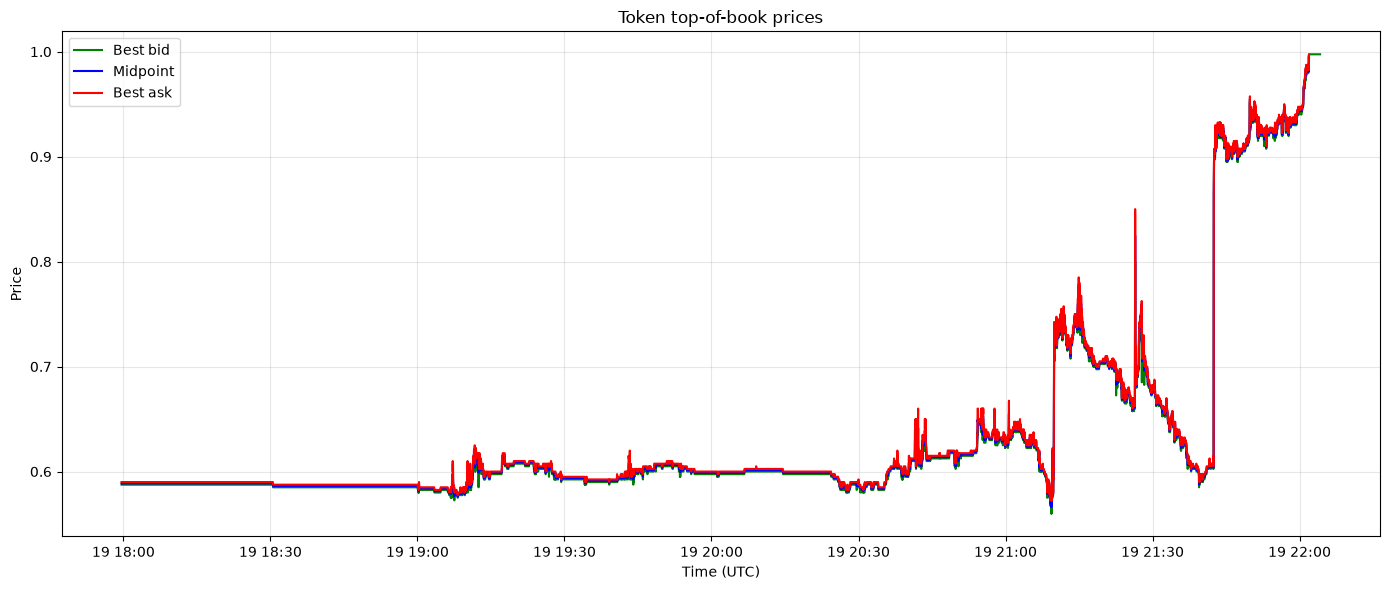

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

db_path = Path("world_cup_final_orderbooks.sqlite3").resolve()
token_id = "21489275813654264105403246157265887827595023709508765470113828829105196462288"

with sqlite3.connect(f"file:{db_path.as_posix()}?mode=ro", uri=True) as con:
    df = pd.read_sql_query(
        """
        SELECT timestamp_utc, best_bid, midpoint, best_ask
        FROM top_of_book_snapshots
        WHERE token_id = ?
        ORDER BY timestamp_utc
        """,
        con,
        params=[token_id],
    )

df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"])

for col in ["best_bid", "midpoint", "best_ask"]:
    df[col] = pd.to_numeric(df[col])

plt.figure(figsize=(14, 6))
plt.plot(df["timestamp_utc"], df["best_bid"], label="Best bid", color="green")
plt.plot(df["timestamp_utc"], df["midpoint"], label="Midpoint", color="blue")
plt.plot(df["timestamp_utc"], df["best_ask"], label="Best ask", color="red")

plt.xlabel("Time (UTC)")
plt.ylabel("Price")
plt.title("Token top-of-book prices")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()